In [1]:
import warnings
import jupyter_client

warnings.filterwarnings(
    "ignore",
    category=DeprecationWarning,
    module=jupyter_client.__name__
)

warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client.session")
warnings.filterwarnings("ignore", category=DeprecationWarning)

warnings.filterwarnings(
    "ignore",
    message=".*datetime.datetime.utcnow.*",
    category=DeprecationWarning
)

# Asszociációs szabályok – Groceries dataset

Ez a notebook az **asszociációs szabálytanulás** gyakorlati példáját mutatja be a klasszikus **Groceries** adathalmazon.  
A cél: gyakran együtt előforduló termékek és mintázatok felfedezése bevásárlókosarakból.

## Az adathalmaz
- Valós szupermarket tranzakciók  
- **9835 kosár**, **169 egyedi termék**  
- Minden sor egy vásárlói tranzakció (itemlista)
- Gyakori termékek: *whole milk*, *yogurt*, *rolls/buns*, *vegetables*

A Groceries dataset kiváló eszköz az Apriori és az FP-Growth algoritmus bemutatásához,  
mivel kicsi, tiszta és sok érdekes szabályt tartalmaz.

## A notebook céljai
- tranzakciós adatok előkészítése  
- gyakori itemhalmazok meghatározása  
- asszociációs szabályok számítása (support, confidence, lift)  
- legérdekesebb szabályok értelmezése




## Adat betöltése és előkészítése

A Groceries dataset tranzakció-alapú (minden sor egy bevásárlókosár, termékek listájával).  
A következő lépésekben:

1. Betöltjük a tranzakciókat egy `.csv` fájlból  
2. Listák listájává alakítjuk a kosarakat  
3. One-hot kódolást készítünk, amelyben minden oszlop egy terméket jelöl  
4. Előkészítjük az adatot az Apriori és FP-Growth algoritmusokhoz


In [2]:
import requests

url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/groceries.csv"
data = requests.get(url).text

transactions = []

for line in data.split("\n"):
    if line.strip():  # üres sorok kiszűrése
        # leszedjük a felesleges idézőjeleket és split
        items = line.replace('"','').split(",")
        transactions.append(items)

len(transactions), transactions[:3]


(9835,
 [['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
  ['tropical fruit', 'yogurt', 'coffee'],
  ['whole milk']])

## A tranzakciók bináris mátrixszá alakítása

A nyers kosárlistákat először one-hot (bináris) formára kell konvertálni, hogy az Apriori algoritmus fel tudja dolgozni.

A TransactionEncoder minden termékhez egy oszlopot hoz létre, és True/False értékekkel jelöli, hogy az adott tranzakció tartalmazza-e az adott terméket.

In [3]:
from mlxtend.preprocessing import TransactionEncoder
import pandas as pd

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

df = pd.DataFrame(te_array, columns=te.columns_)
df.head()


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


## Asszociációs szabályok generálása

A gyakori itemhalmazokból a association_rules() függvénnyel hozunk létre asszociációs szabályokat.
Lift alapján rendezzük őket, mert ez mutatja meg a legerősebben, hogy két termék vártnál gyakrabban fordul-e elő együtt.

In [4]:
from mlxtend.frequent_patterns import apriori

# --- Run Apriori algorithm ---
# min_support: milyen gyakran kell szerepelnie egy itemhalmaznak a szabályhoz
frequent_itemsets = apriori(df,
                            min_support=0.01,   # 1% minimum gyakoriság (~100 tranzakció)
                            use_colnames=True)

frequent_itemsets.head(10)


,support,itemsets
0,0.033452,(UHT-milk)
1,0.017692,(baking powder)
2,0.052466,(beef)
3,0.033249,(berries)
4,0.026029,(beverages)
5,0.080529,(bottled beer)
6,0.110524,(bottled water)
7,0.064870,(brown bread)
8,0.055414,(butter)
9,0.027961,(butter milk)


## Asszociációs szabályok előállítása lift alapján

A gyakori itemhalmazokból asszociációs szabályokat generálunk, majd a szabályokat lift szerint sorba rendezzük.
A lift mutatja meg, hogy két termék vártnál nagyobb valószínűséggel fordul-e elő együtt, ezért ez a leghasznosabb rendezési szempont.

In [5]:
from mlxtend.frequent_patterns import association_rules

# --- Generate association rules ---
rules = association_rules(frequent_itemsets,
                          metric="lift",
                          min_threshold=1.0)

# rendezés lift szerint (leghasznosabb mutató)
rules = rules.sort_values(by="lift", ascending=False)

rules.head(20)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
439,(curd),"(yogurt, whole milk)",0.053279,0.056024,0.010066,0.188931,3.372304,1.0,0.007081,1.163866,0.743056,0.101434,0.140795,0.184302
438,"(yogurt, whole milk)",(curd),0.056024,0.053279,0.010066,0.179673,3.372304,1.0,0.007081,1.154078,0.745217,0.101434,0.133507,0.184302
423,(root vegetables),"(citrus fruit, other vegetables)",0.108998,0.028876,0.010371,0.095149,3.295045,1.0,0.007224,1.073242,0.781720,0.081340,0.068243,0.227152
418,"(citrus fruit, other vegetables)",(root vegetables),0.028876,0.108998,0.010371,0.359155,3.295045,1.0,0.007224,1.390354,0.717225,0.081340,0.280759,0.227152
539,"(yogurt, other vegetables)",(whipped/sour cream),0.043416,0.071683,0.010168,0.234192,3.267062,1.0,0.007056,1.212206,0.725409,0.096899,0.175058,0.188018
542,(whipped/sour cream),"(yogurt, other vegetables)",0.071683,0.043416,0.010168,0.141844,3.267062,1.0,0.007056,1.114697,0.747497,0.096899,0.102895,0.188018
495,(root vegetables),"(tropical fruit, other vegetables)",0.108998,0.035892,0.012303,0.112873,3.144780,1.0,0.008391,1.086776,0.765445,0.092791,0.079847,0.227825
490,"(tropical fruit, other vegetables)",(root vegetables),0.035892,0.108998,0.012303,0.342776,3.144780,1.0,0.008391,1.355705,0.707403,0.092791,0.262376,0.227825
4,(root vegetables),(beef),0.108998,0.052466,0.017387,0.159515,3.040367,1.0,0.011668,1.127366,0.753189,0.120677,0.112977,0.245455
5,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455


### Mit jelentenek az asszociációs szabályok oszlopai?

Az association_rules() több mutatót is kiszámít egy szabályra (antecedents → consequents).
A legfontosabb oszlopok rövid jelentése:
- antecedents – A szabály bal oldala (ha ezek a termékek szerepelnek…).
- consequents – A szabály jobb oldala (…akkor ez(ek) is gyakran szerepel(nek)).
- antecedent support – A bal oldali termékek előfordulási aránya.
- consequent support – A jobb oldali termékek előfordulási aránya.
- support – A szabály együttes előfordulási aránya (A ∪ B).
- confidence – Valószínűsége annak, hogy B megtörténik, ha A megtörtént.
- lift – A kapcsolat erőssége; >1 esetén A és B vártnál gyakrabban fordul elő együtt.
- leverage – Mennyivel tér el az együttes előfordulás a véletlentől.
- conviction – A kapcsolat „biztossága”; nagyobb érték → erősebb irányított kapcsolat.
- jaccard – Normalizált együtt-előfordulás (metszet / unió).
- certainty, kulczynski, zhangs_metric – Alternatív szabályminőségi mutatók.

##  Egytermék–egytermék szabályok szűrése

A szabályok közül csak azokat választjuk ki, ahol mind az antecedens, mind a következmény pontosan egyetlen termékből áll.
Ez segít a legegyszerűbben értelmezhető, 1 → 1 típusú szabályok vizsgálatában

In [6]:
rules_filtered = rules[(rules['antecedents'].apply(len) == 1) &
                       (rules['consequents'].apply(len) == 1)]

rules_filtered.head(15)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,(root vegetables),(beef),0.108998,0.052466,0.017387,0.159515,3.040367,1.0,0.011668,1.127366,0.753189,0.120677,0.112977,0.245455
5,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455
142,(curd),(whipped/sour cream),0.053279,0.071683,0.010473,0.196565,2.742150,1.0,0.006654,1.155435,0.671077,0.091474,0.134525,0.171332
143,(whipped/sour cream),(curd),0.071683,0.053279,0.010473,0.146099,2.742150,1.0,0.006654,1.108701,0.684381,0.091474,0.098044,0.171332
321,(pip fruit),(tropical fruit),0.075648,0.104931,0.020437,0.270161,2.574648,1.0,0.012499,1.226392,0.661650,0.127619,0.184600,0.232464
320,(tropical fruit),(pip fruit),0.104931,0.075648,0.020437,0.194767,2.574648,1.0,0.012499,1.147931,0.683297,0.127619,0.128868,0.232464
73,(butter),(whipped/sour cream),0.055414,0.071683,0.010168,0.183486,2.559698,1.0,0.006196,1.136928,0.645075,0.086957,0.120437,0.162665
72,(whipped/sour cream),(butter),0.071683,0.055414,0.010168,0.141844,2.559698,1.0,0.006196,1.100716,0.656380,0.086957,0.091500,0.162665
260,(onions),(other vegetables),0.031012,0.193493,0.014235,0.459016,2.372268,1.0,0.008234,1.490817,0.596976,0.067698,0.329227,0.266292
261,(other vegetables),(onions),0.193493,0.031012,0.014235,0.073568,2.372268,1.0,0.008234,1.045936,0.717244,0.067698,0.043918,0.266292


Magyarázat:

Tipikus szabályok:

- “whole milk → yogurt”
- “root vegetables → other vegetables”
- “curd, yogurt → whole milk”


## Az itemhalmazok átalakítása olvasható szöveggé

Az antecedents és consequents eredetileg Python halmazok ({'yogurt'} stb.).
A könnyebb olvashatóság érdekében ezeket szöveggé alakítjuk, vesszővel elválasztva az elemeket.

In [7]:
def to_str(itemset):
    return ", ".join(list(itemset))

rules_display = rules_filtered.copy()
rules_display["antecedents"] = rules_display["antecedents"].apply(to_str)
rules_display["consequents"] = rules_display["consequents"].apply(to_str)

rules_display.head(15)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
4,root vegetables,beef,0.108998,0.052466,0.017387,0.159515,3.040367,1.0,0.011668,1.127366,0.753189,0.120677,0.112977,0.245455
5,beef,root vegetables,0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455
142,curd,whipped/sour cream,0.053279,0.071683,0.010473,0.196565,2.742150,1.0,0.006654,1.155435,0.671077,0.091474,0.134525,0.171332
143,whipped/sour cream,curd,0.071683,0.053279,0.010473,0.146099,2.742150,1.0,0.006654,1.108701,0.684381,0.091474,0.098044,0.171332
321,pip fruit,tropical fruit,0.075648,0.104931,0.020437,0.270161,2.574648,1.0,0.012499,1.226392,0.661650,0.127619,0.184600,0.232464
320,tropical fruit,pip fruit,0.104931,0.075648,0.020437,0.194767,2.574648,1.0,0.012499,1.147931,0.683297,0.127619,0.128868,0.232464
73,butter,whipped/sour cream,0.055414,0.071683,0.010168,0.183486,2.559698,1.0,0.006196,1.136928,0.645075,0.086957,0.120437,0.162665
72,whipped/sour cream,butter,0.071683,0.055414,0.010168,0.141844,2.559698,1.0,0.006196,1.100716,0.656380,0.086957,0.091500,0.162665
260,onions,other vegetables,0.031012,0.193493,0.014235,0.459016,2.372268,1.0,0.008234,1.490817,0.596976,0.067698,0.329227,0.266292
261,other vegetables,onions,0.193493,0.031012,0.014235,0.073568,2.372268,1.0,0.008234,1.045936,0.717244,0.067698,0.043918,0.266292


### Asszociációs szabályok hálógráfja (Top 40 szabály lift alapján)

A legmagasabb lift értékű szabályokból irányított hálózatot építünk:

- minden csúcs egy termék,
- az él az antecedens → consequens szabályt jelöli,
- az él vastagsága a lift értékével arányos.

Ez a vizualizáció megmutatja, mely termékek között vannak a legerősebb, vártnál gyakoribb kapcsolatok.

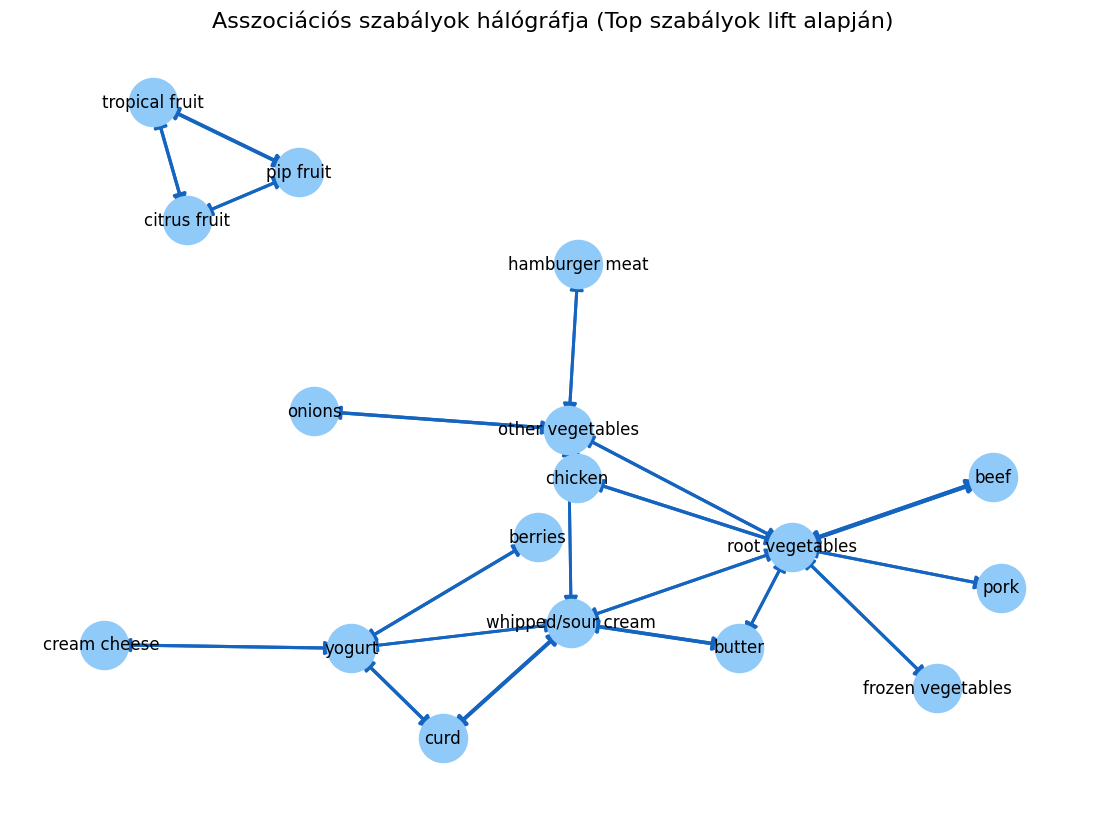

In [8]:
import networkx as nx
import matplotlib.pyplot as plt

# --- Select top rules for visualization ---
top_rules = rules_filtered.sort_values("lift", ascending=False).head(40)

# --- Create graph ---
G = nx.DiGraph()

# Add nodes + edges
for _, row in top_rules.iterrows():

    antecedent = list(row['antecedents'])[0]
    consequent = list(row['consequents'])[0]
    lift = row['lift']

    # add nodes with support as attribute
    G.add_node(antecedent)
    G.add_node(consequent)

    # add edge with lift weight
    G.add_edge(antecedent, consequent, weight=lift)

# --- Layout ---
pos = nx.spring_layout(G, k=0.8, seed=42)

# --- Draw nodes ---
plt.figure(figsize=(14, 10))
nx.draw_networkx_nodes(G, pos,
                       node_size=1200,
                       node_color="#90caf9")

# --- Draw edges (edge width = lift) ---
edge_weights = [G[u][v]['weight'] for u,v in G.edges()]
nx.draw_networkx_edges(G, pos,
                       width=edge_weights,
                       edge_color="#1565c0",
                       arrowsize=20)

# --- Draw labels ---
nx.draw_networkx_labels(G, pos,
                        font_size=12,
                        font_family="sans-serif")

plt.title("Asszociációs szabályok hálógráfja (Top szabályok lift alapján)", fontsize=16)
plt.axis("off")
plt.show()


## Lift–Support Scatter Plot

- Bal alsó sarok: ritka + gyenge szabályok
- Jobb alsó sarok: gyakori, de gyenge kapcsolat (lift ≈ 1)
- Bal felső sarok: ritka, de erős szabályok
- Jobb felső sarok: nagyon értékes szabályok
  - magas support
  - magas lift
  - nagy confidence (nagyon nagy pont)

Ez remekül kiegészíti a hálógráfot, mert más dimenzióból mutatja meg a szabályok minőségét.

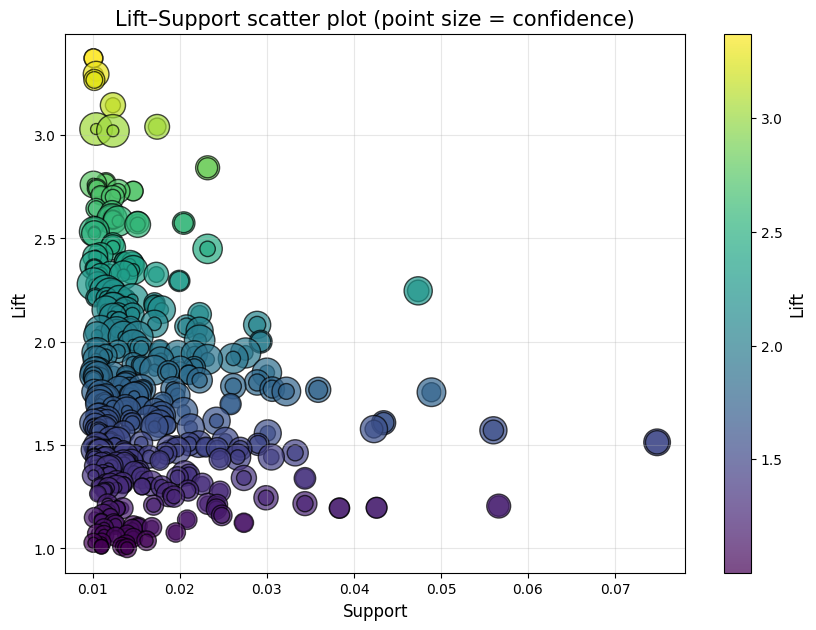

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Use all rules or the filtered ones (recommended)
rules_plot = rules.copy()

# Extract values
supports = rules_plot["support"].values
lifts = rules_plot["lift"].values
confidences = rules_plot["confidence"].values

# Normalize confidence for point sizes
conf_scaled = 500 * (confidences - confidences.min()) / (confidences.max() - confidences.min() + 1e-9) + 50

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    supports,
    lifts,
    c=lifts,
    s=conf_scaled,
    cmap="viridis",
    alpha=0.7,
    edgecolors="black"
)

cbar = plt.colorbar(scatter)
cbar.set_label("Lift", fontsize=12)

plt.xlabel("Support", fontsize=12)
plt.ylabel("Lift", fontsize=12)
plt.title("Lift–Support scatter plot (point size = confidence)", fontsize=15)

plt.grid(alpha=0.3)
plt.show()


## Top asszociációs szabályok lift szerint

A lift a szabályok egyik legfontosabb mutatója: azt méri, hogy az antecedens
valóban erős előrejelzője-e a consequensnek.  

- **lift = 1** → nincs kapcsolat  
- **lift > 1** → pozitív, erős együttjárás  
- **lift >> 1** → kiemelten jó szabály  

Az alábbiakban a szabályokat lift szerint rendezzük, és a legérdekesebbeket jelenítjük meg.


In [10]:
# Sort rules by lift (descending)
rules_sorted = rules.sort_values(by="lift", ascending=False)

# Display top 20
rules_sorted.head(20)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
439,(curd),"(yogurt, whole milk)",0.053279,0.056024,0.010066,0.188931,3.372304,1.0,0.007081,1.163866,0.743056,0.101434,0.140795,0.184302
438,"(yogurt, whole milk)",(curd),0.056024,0.053279,0.010066,0.179673,3.372304,1.0,0.007081,1.154078,0.745217,0.101434,0.133507,0.184302
423,(root vegetables),"(citrus fruit, other vegetables)",0.108998,0.028876,0.010371,0.095149,3.295045,1.0,0.007224,1.073242,0.781720,0.081340,0.068243,0.227152
418,"(citrus fruit, other vegetables)",(root vegetables),0.028876,0.108998,0.010371,0.359155,3.295045,1.0,0.007224,1.390354,0.717225,0.081340,0.280759,0.227152
539,"(yogurt, other vegetables)",(whipped/sour cream),0.043416,0.071683,0.010168,0.234192,3.267062,1.0,0.007056,1.212206,0.725409,0.096899,0.175058,0.188018
542,(whipped/sour cream),"(yogurt, other vegetables)",0.071683,0.043416,0.010168,0.141844,3.267062,1.0,0.007056,1.114697,0.747497,0.096899,0.102895,0.188018
495,(root vegetables),"(tropical fruit, other vegetables)",0.108998,0.035892,0.012303,0.112873,3.144780,1.0,0.008391,1.086776,0.765445,0.092791,0.079847,0.227825
490,"(tropical fruit, other vegetables)",(root vegetables),0.035892,0.108998,0.012303,0.342776,3.144780,1.0,0.008391,1.355705,0.707403,0.092791,0.262376,0.227825
4,(root vegetables),(beef),0.108998,0.052466,0.017387,0.159515,3.040367,1.0,0.011668,1.127366,0.753189,0.120677,0.112977,0.245455
5,(beef),(root vegetables),0.052466,0.108998,0.017387,0.331395,3.040367,1.0,0.011668,1.332628,0.708251,0.120677,0.249603,0.245455


## A szabályok szöveges formázása könnyebb áttekintéshez

A szabályok elemei eredetileg halmazként jelennek meg.
Az itemset_to_str() függvénnyel ezeket olvasható szöveggé alakítjuk, majd csak a legfontosabb mutatókat jelenítjük meg:
- support – együtt előfordulás aránya
- confidence – valószínűsége, hogy a következmény bekövetkezik az antecedens után
- lift – a kapcsolat erőssége ( >1 → vártnál erősebb együttjárás )

In [11]:
def itemset_to_str(itemset):
    return ", ".join(list(itemset))

rules_pretty = rules_sorted.copy()

rules_pretty["antecedents"] = rules_pretty["antecedents"].apply(itemset_to_str)
rules_pretty["consequents"] = rules_pretty["consequents"].apply(itemset_to_str)

rules_pretty[["antecedents", "consequents", "support", "confidence", "lift"]].head(20)


,antecedents,consequents,support,confidence,lift
439,curd,"yogurt, whole milk",0.010066,0.188931,3.372304
438,"yogurt, whole milk",curd,0.010066,0.179673,3.372304
423,root vegetables,"citrus fruit, other vegetables",0.010371,0.095149,3.295045
418,"citrus fruit, other vegetables",root vegetables,0.010371,0.359155,3.295045
539,"yogurt, other vegetables",whipped/sour cream,0.010168,0.234192,3.267062
542,whipped/sour cream,"yogurt, other vegetables",0.010168,0.141844,3.267062
495,root vegetables,"tropical fruit, other vegetables",0.012303,0.112873,3.144780
490,"tropical fruit, other vegetables",root vegetables,0.012303,0.342776,3.144780
4,root vegetables,beef,0.017387,0.159515,3.040367
5,beef,root vegetables,0.017387,0.331395,3.040367


## Heatmap a top asszociációs szabályokról

A következő hőtérkép a legjobb szabályokat mutatja be (lift szerint rendezve).  
A sorok az antecedensek, az oszlopok a consequensek, a szín pedig a lift értéke.  

Ez jól szemlélteti, mely termékek között a legerősebb az együttjárás.


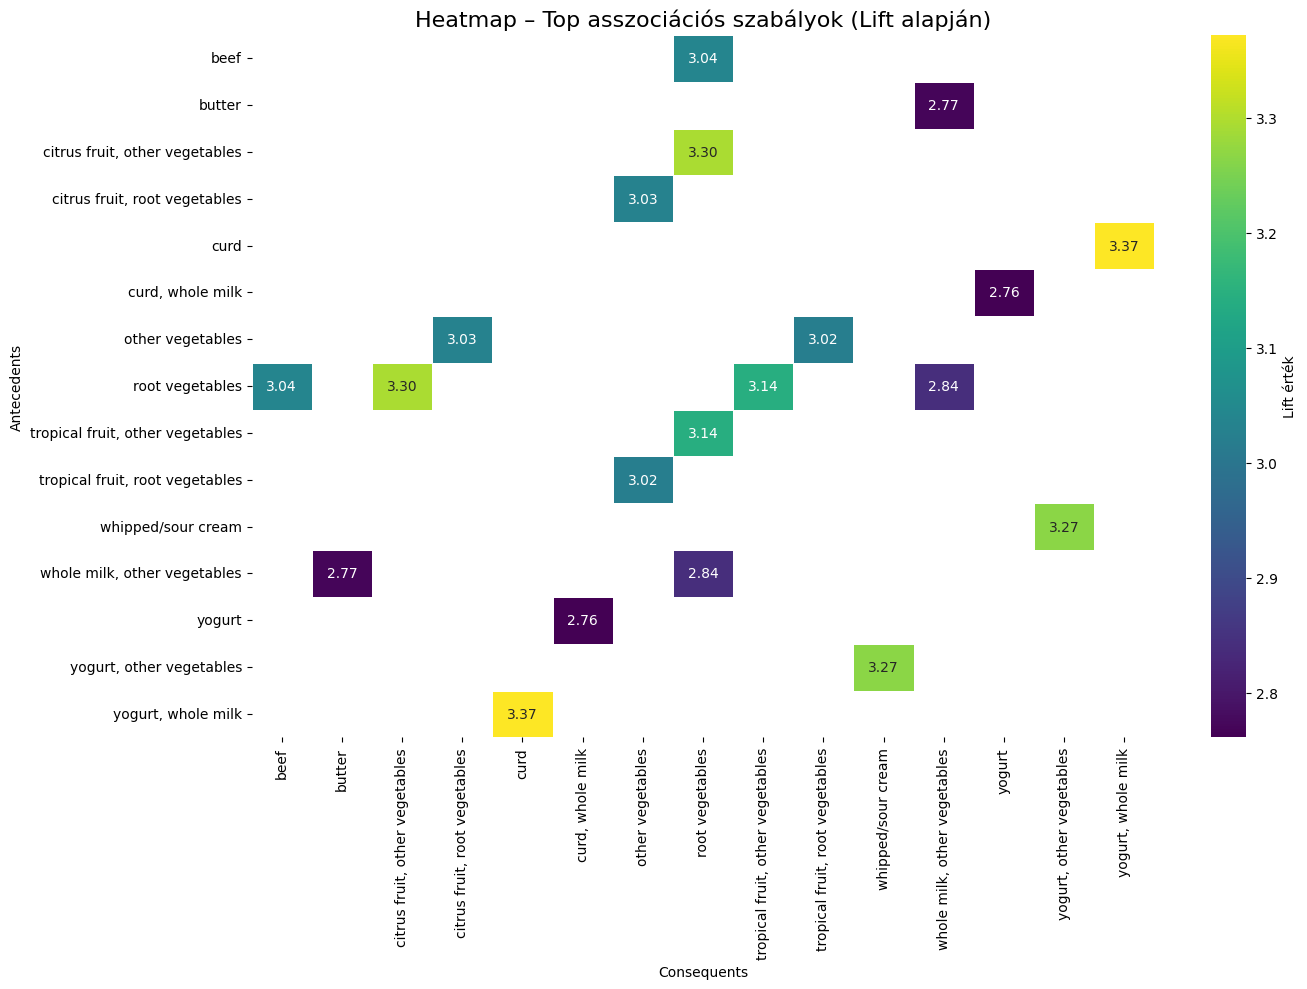

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# --- Select top 20 rules by lift ---
top_rules = rules_sorted.head(20).copy()

# Convert frozenset → string for readability
top_rules["antecedents"] = top_rules["antecedents"].apply(lambda x: ", ".join(list(x)))
top_rules["consequents"] = top_rules["consequents"].apply(lambda x: ", ".join(list(x)))

# --- Pivot table for heatmap ---
heatmap_data = top_rules.pivot_table(
    index="antecedents",
    columns="consequents",
    values="lift"
)

plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    cbar_kws={"label": "Lift érték"}
)

plt.title("Heatmap – Top asszociációs szabályok (Lift alapján)", fontsize=16)
plt.xlabel("Consequents")
plt.ylabel("Antecedents")
plt.tight_layout()
plt.show()


## Példa a lift értelmezésére

Tegyük fel, hogy a szabály:
- joghurt → túró (lift = 3.37)

Mit jelent ez?

- Ha egy vásárló vesz joghurtot, akkor 3.37-szer nagyobb eséllyel vesz túrót is, mint amit a két termék önálló előfordulása alapján várnánk.

- Vagyis a két termék szignifikánsan gyakrabban jelenik meg együtt a kosarakban, mint véletlen egybeesés alapján indokolt lenne.

- Ez erős, üzletileg jól hasznosítható kapcsolat (pl. polcelhelyezés, csomagajánlat, kuponok).

## Support–Confidence diagram

Ez a klasszikus „érdekesség-térkép”, amely az asszociációs szabályokat két fő tengelyen mutatja:

- **Support (támogatottság)** – milyen gyakran fordul elő a szabály  
- **Confidence (bizalom)** – az antecedens mennyire jó előrejelző  
- **Szín:** lift érték  
- **Pontméret:** lift (erősség)

A grafikon segít felismerni:

- gyenge szabályokat (alacsony lift)  
- ritka, de erős szabályokat  
- gyakori és erős szabályokat (optimális régió)  


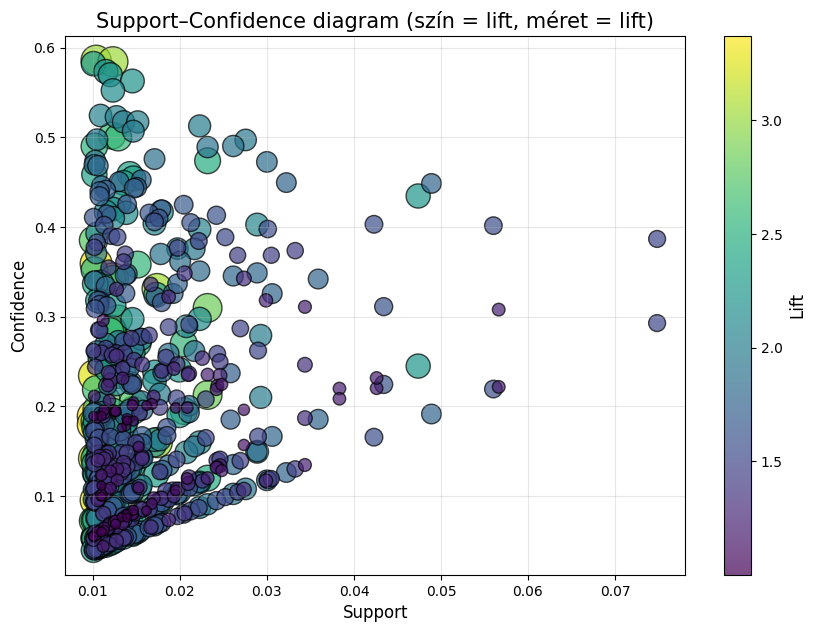

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# We use the already calculated 'rules' DataFrame
supports = rules['support'].values
confidences = rules['confidence'].values
lifts = rules['lift'].values

# Size scaling based on lift (optional)
sizes = 500 * (lifts - lifts.min()) / (lifts.max() - lifts.min() + 1e-9) + 40

plt.figure(figsize=(10, 7))

scatter = plt.scatter(
    supports,
    confidences,
    c=lifts,
    s=sizes,
    cmap='viridis',
    alpha=0.7,
    edgecolor='black'
)

# Colorbar for lift
cbar = plt.colorbar(scatter)
cbar.set_label("Lift", fontsize=12)

plt.xlabel("Support", fontsize=12)
plt.ylabel("Confidence", fontsize=12)
plt.title("Support–Confidence diagram (szín = lift, méret = lift)", fontsize=15)

plt.grid(alpha=0.3)
plt.show()


Magyarázat:

A grafikonon három régió különül el:

- 1. Alacsony support, magas lift
  - Ritka, de nagyon informatív szabályok.
  - Pl. speciális termékek kapcsolatai.

- 2. Magas support, alacsony lift
  - Gyakori, de semmi extra:
  - pl. whole milk → whole milk-szerű triviális kapcsolatok.

- 3. Középen / jobb-felső sarok
  - A valóban értékes szabályok!
  - gyakori + erős együttjárás.

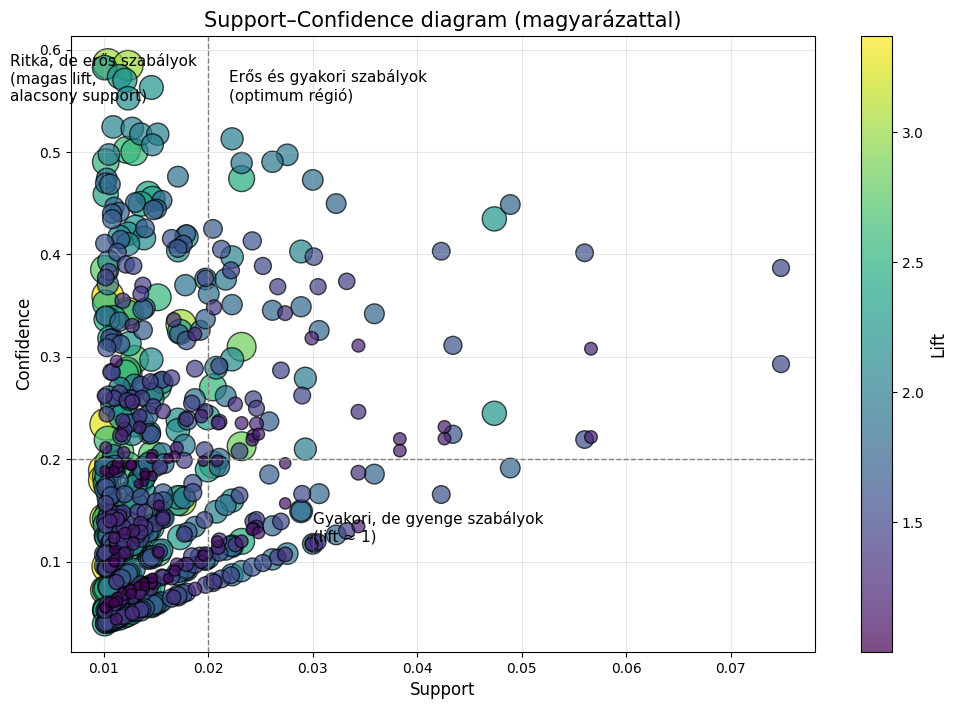

In [14]:
import matplotlib.pyplot as plt
import numpy as np

supports = rules['support'].values
confidences = rules['confidence'].values
lifts = rules['lift'].values

sizes = 500 * (lifts - lifts.min()) / (lifts.max() - lifts.min() + 1e-9) + 40

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    supports,
    confidences,
    c=lifts,
    s=sizes,
    cmap='viridis',
    alpha=0.7,
    edgecolor='black'
)

# --- Colorbar ---
cbar = plt.colorbar(scatter)
cbar.set_label("Lift", fontsize=12)

# --- Education-friendly guide lines ---
plt.axhline(0.2, color='gray', linestyle='--', linewidth=1)
plt.axvline(0.02, color='gray', linestyle='--', linewidth=1)

# --- Annotations (Hungarian) ---
plt.text(0.001, 0.55,
         "Ritka, de erős szabályok\n(magas lift,\nalacsony support)",
         fontsize=11, color='black')

plt.text(0.022, 0.55,
         "Erős és gyakori szabályok\n(optimum régió)",
         fontsize=11, color='black')

plt.text(0.03, 0.12,
         "Gyakori, de gyenge szabályok\n(lift ≈ 1)",
         fontsize=11, color='black')

plt.xlabel("Support", fontsize=12)
plt.ylabel("Confidence", fontsize=12)
plt.title("Support–Confidence diagram (magyarázattal)", fontsize=15)
plt.grid(alpha=0.3)
plt.show()


## Co-occurrence mátrix + Heatmap

A co-occurrence (együttfrodulási) mátrix azt mutatja, hogy mely termékek
milyen gyakran szerepelnek **együttesen** ugyanabban a bevásárlókosárban.

A hőtérkép vizuálisan kiemeli a természetes termékcsoportokat
(például zöldségek, tejtermékek, pékáruk), és segít megérteni, hogy miért
kapunk bizonyos asszociációs szabályokat.

A sorok és oszlopok termékeket jelölnek, a cellák pedig az
együttfrodulás gyakoriságát.


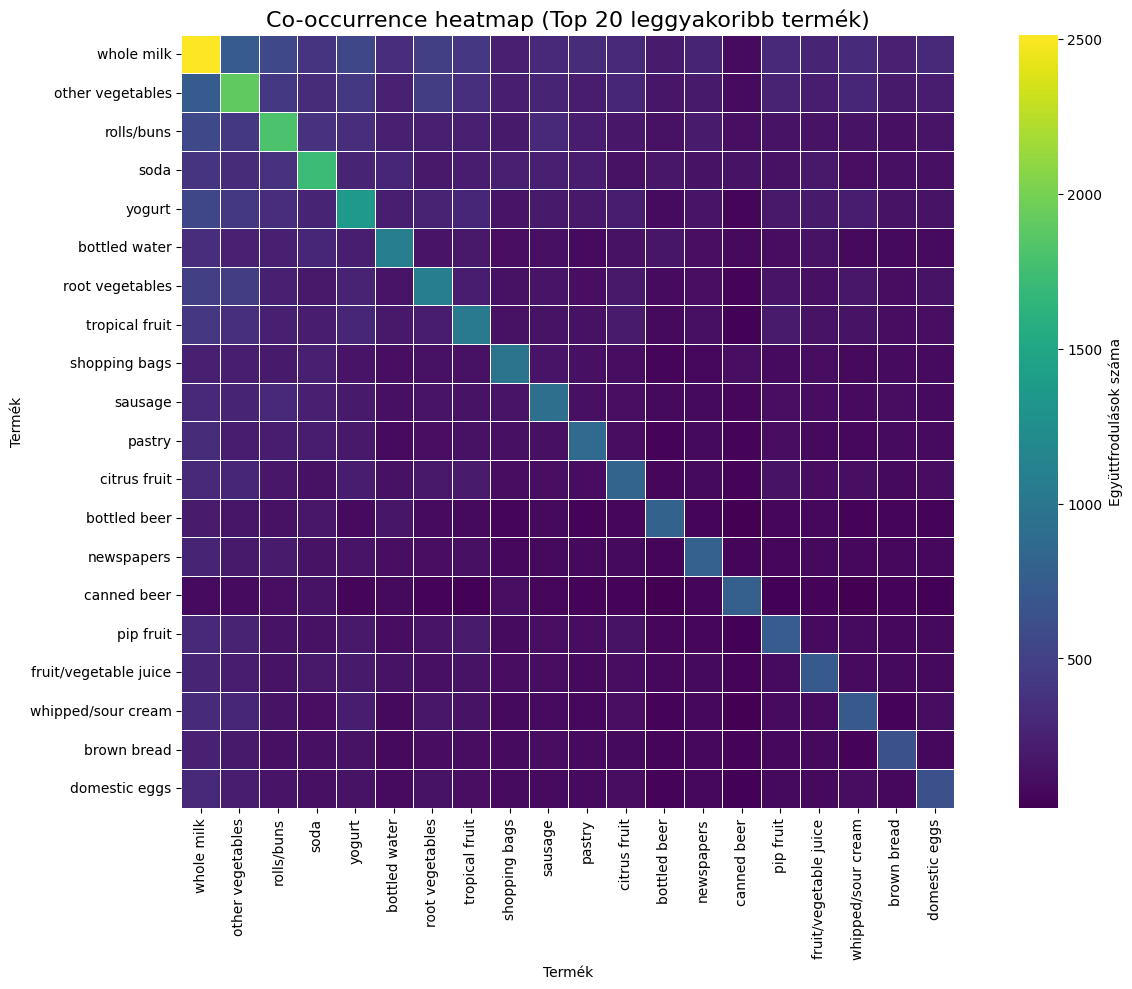

In [15]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Top 20 termék támogatottság szerint ---
item_supports = df.mean().sort_values(ascending=False)
top_items = item_supports.head(20).index

# --- 2. One-hot boolean → int konverzió ---
df_int = df[top_items].astype(int)

# --- 3. Co-occurrence mátrix számítása ---
co_matrix = df_int.T.dot(df_int)

plt.figure(figsize=(14, 10))
sns.heatmap(
    co_matrix,
    cmap="viridis",
    annot=False,
    linewidths=0.5,
    square=True,
    cbar_kws={"label": "Együttfrodulások száma"}
)

plt.title("Co-occurrence heatmap (Top 20 leggyakoribb termék)", fontsize=16)
plt.xlabel("Termék")
plt.ylabel("Termék")
plt.tight_layout()
plt.show()


## FP-Growth vs Apriori – Összehasonlítás

Az Apriori algoritmus lépésről lépésre generálja a jelölt itemhalmazokat,
és minden szinten végigvizsgálja a teljes adatbázist.  
Ez **exponenciális skálázódást** eredményez nagy adaton.

Ezzel szemben az FP-Growth algoritmus:

- **nem generál jelölteket**,
- egy **kompakt FP-tree** strukturába sűríti az adatot,
- majd ezen hajtja végre a mintakeresést.

Ennek eredménye, hogy FP-Growth **nagyságrendekkel gyorsabb**, főleg nagy adatnál.

| Algoritmus | Jelöltgenerálás | Memória | Futásidő nagy adaton | Ipari használat |
|------------|-----------------|---------|------------------------|------------------|
| **Apriori** | Igen | Nagy | Lassú | Ritka |
| **FP-Growth** | Nem | Közepes | Gyors | Standard |

Az alábbiakban lefuttatjuk mindkettőt ugyanazon a `min_support` küszöbön, és megmérjük a futási időt.


In [18]:
from mlxtend.frequent_patterns import fpgrowth

fpgrowth_itemsets = fpgrowth(df, min_support=0.01, use_colnames=True)
fpgrowth_itemsets.head()


,support,itemsets
0,0.082766,(citrus fruit)
1,0.058566,(margarine)
2,0.017692,(semi-finished bread)
3,0.139502,(yogurt)
4,0.104931,(tropical fruit)


Ez csak azt mutatja:

mely tételek elég gyakoriak ahhoz, hogy továbblépjen rájuk az algoritmus.

-  Ez FP-Growthnak csak az ELSŐ lépése.
-  Nincs benne, hogy mi fordul elő együtt a joghurttal.

## Asszociációs szabályok generálása

A szabályokat NEM az Apriori vagy FP-Growth generálja!
A szabályokat mindig a association_rules() funkció csinálja.

In [22]:
from mlxtend.frequent_patterns import association_rules

rules_fpg = association_rules(
    fpgrowth_itemsets,
    metric="lift",          # vagy "confidence"
    min_threshold=1.0       # lift >= 1
)


In [23]:
rules_fpg[rules_fpg['antecedents'].apply(lambda x: 'yogurt' in x)]


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2,(yogurt),(citrus fruit),0.139502,0.082766,0.021657,0.155248,1.875752,1.0,0.010111,1.085803,0.542570,0.107957,0.079023,0.208459
16,"(yogurt, citrus fruit)",(whole milk),0.021657,0.255516,0.010269,0.474178,1.855768,1.0,0.004736,1.415849,0.471348,0.038476,0.293710,0.257185
17,"(yogurt, whole milk)",(citrus fruit),0.056024,0.082766,0.010269,0.183303,2.214725,1.0,0.005633,1.123103,0.581028,0.079905,0.109609,0.153691
19,(yogurt),"(citrus fruit, whole milk)",0.139502,0.030503,0.010269,0.073615,2.413350,1.0,0.006014,1.046538,0.680580,0.064290,0.044468,0.205141
44,(yogurt),(margarine),0.139502,0.058566,0.014235,0.102041,1.742312,1.0,0.006065,1.048415,0.495120,0.077434,0.046179,0.172548
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
523,"(yogurt, other vegetables)",(whipped/sour cream),0.043416,0.071683,0.010168,0.234192,3.267062,1.0,0.007056,1.212206,0.725409,0.096899,0.175058,0.188018
525,(yogurt),"(whipped/sour cream, other vegetables)",0.139502,0.028876,0.010168,0.072886,2.524073,1.0,0.006139,1.047470,0.701704,0.064267,0.045318,0.212499
548,(yogurt),(berries),0.139502,0.033249,0.010574,0.075802,2.279848,1.0,0.005936,1.046043,0.652383,0.065204,0.044017,0.196922
558,(yogurt),(domestic eggs),0.139502,0.063447,0.014337,0.102770,1.619775,1.0,0.005486,1.043827,0.444661,0.076011,0.041987,0.164366
